In [7]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [37]:
start_row = 1

In [40]:
all_files = glob.glob('Group data/ASD/Datacombined/*.asd.txt')

samples = sorted(set(
    os.path.basename(f).split('.')[0][:9]  # MM_350000
    for f in all_files
))
print(len(samples))
print(samples)

333
['LMW600000', 'LMW600001', 'LMW600002', 'LMW600003', 'LMW600004', 'LMW600005', 'LMW600006', 'LMW600007', 'LMW600008', 'LMW600009', 'LMW700000', 'LMW700001', 'LMW700002', 'LMW700003', 'LMW700004', 'LMW700005', 'LMW700006', 'LMW700007', 'LMW700008', 'LMW700009', 'LMW800000', 'LMW800001', 'LMW800002', 'LMW800003', 'LMW800004', 'LMW800005', 'LMW800006', 'LMW800007', 'LMW800008', 'LMW800009', 'LMW800010', 'LMW800011', 'LMW800012', 'LMW800013', 'LMW800014', 'LMW800015', 'LMW800016', 'LMW800017', 'LMW800018', 'LMW800019', 'LMW_10000', 'LMW_11000', 'LMW_12000', 'LMW_13000', 'LMW_13_a0', 'LMW_14000', 'LMW_15000', 'LMW_16000', 'LMW_17000', 'LMW_18000', 'LMW_19000', 'LMW_20000', 'LMW_20001', 'LMW_21000', 'LMW_22000', 'LMW_23000', 'LMW_24000', 'LMW_30000', 'LMW_40000', 'LMW_50000', 'LMW_7 200', 'LMW_70000', 'LMW_7_200', 'LMW_90000', 'LMW_9_200', 'LMW_9_300', 'MM100000', 'MM100001', 'MM1000010', 'MM1000011', 'MM1000012', 'MM1000013', 'MM1000014', 'MM1000015', 'MM1000016', 'MM1000017', 'MM100001

In [ ]:
# output folder
out_dir = 'Group data/ASD/Figures'
os.makedirs(out_dir, exist_ok=True)

samples = [
    # LMW series
    'LMW_10000',    'LMW_20000',    'LMW_30000',    'LMW_40000',    'LMW_50000',    'LMW60000',    'LMW_70000',    'LMW80000',
    # MM series
    'MM100000',    'MM200000',    'MM300000',    'MM400000',    'MM500000',    'MM600000',    'MM700000',    'MM800000',    'MM900000',
    'MM1000010',    'mm1200000',    'mm1300000',    'mm1400000',    'mm1500000',    'mm1600000',    'mm1700000',    'mm1800000',    'mm1900000',
    'mm2000000',    'mm2100000',    'mm2200000',    'mm2400000',    'mm2500000',    'mm2600000',    'mm2700000',    'mm2800000',
    'MM_3100000',    'MM_3200000',    'MM_3300000',    'MM_3400000',    'MM_3500000',
    # MM23 series
    'MM23-100000',    'MM23-200000',]


for sample in samples:
    print(f'Processing {sample}...')

    files = sorted(glob.glob(f'Group data/ASD/Datacombined/{sample}*.asd.txt'))

    if len(files) == 0:
        print(f'No files found for {sample}')
        continue

    # --- YOUR SAME CODE ---
    dfs = []
    for f in files:
        name = os.path.basename(f)
        df = pd.read_csv(f, sep='\t', names=['Wavelength', name], skiprows=start_row)
        df = df.set_index('Wavelength')
        dfs.append(df)

    alldata = pd.concat(dfs, axis=1)
    alldata['Avg refl'] = alldata.mean(axis=1)

    wl = alldata.index.astype(float)
    refl_avg = alldata['Avg refl']

    # --- PLOT ---
    plt.figure()
    plt.plot(wl, refl_avg, label='Average')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance')
    plt.grid()
    plt.title(f'Average spectrum — {sample}')
    plt.ylim(0, 1)
    plt.legend()

    # save
    plt.savefig(f'{out_dir}/{sample}_average_spectrum.png')
    plt.close()

print("Done!")

Processing LMW_10000...
Processing LMW_20000...
Processing LMW_30000...
Processing LMW_40000...
Processing LMW_50000...
Processing LMW60000...
Processing LMW_70000...
Processing LMW80000...
Processing MM100000...
Processing MM200000...
Processing MM300000...
Processing MM400000...
Processing MM500000...
Processing MM600000...
Processing MM700000...
Processing MM800000...
Processing MM900000...
Processing MM1000010...
Processing mm1200000...
Processing mm1300000...
Processing mm1400000...
Processing mm1500000...
Processing mm1600000...
Processing mm1700000...
Processing mm1800000...
Processing mm1900000...
Processing mm2000000...
Processing mm2100000...
Processing mm2200000...
Processing mm2400000...
No files found for mm2400000
Processing mm2500000...
Processing mm2600000...
Processing mm2700000...
Processing mm2800000...
No files found for mm2800000
Processing MM_3100000...
Processing MM_3200000...
Processing MM_3300000...
Processing MM_3400000...
Processing MM_3500000...
Processing M

# pca and stacked plot of all samples 

In [54]:
def compute_average(pattern):

    files = sorted(glob.glob(pattern))

    if len(files) == 0:
        print(f"No files found for pattern: {pattern}")
        return None

    dfs = []
    for f in files:
        name = os.path.basename(f)
        df = pd.read_csv(f, sep='\t', names=['Wavelength', name], skiprows=start_row)
        df = df.set_index('Wavelength')
        dfs.append(df)

    alldata = pd.concat(dfs, axis=1)
    avg = alldata.mean(axis=1)

    return avg

In [102]:
samples = [
    # LMW series
    'LMW_10',    'LMW_20',    'LMW_30',    'LMW_40',    'LMW_50',    'LMW60',    'LMW_70',    'LMW80', 'LMW_90',
    'LMW_240','LMW_230','LMW_220','LMW_210','LMW_200',
    'LMW_190','LMW_180','LMW_170','LMW_160','LMW_150',
    'LMW_140','LMW_130','LMW_120','LMW_110',
    # MM series
    'MM10',    'MM20',    'MM30',    'MM40',    'MM50',    'MM60',    'MM70',    'MM80',    'MM90',
    'MM10',    'mm120',    'mm130',    'mm140',    'mm150',    'mm160',    'mm170',    'mm180',    'mm190',
    'mm200',    'mm210',    'mm220',    'mm240',    'mm250',    'mm260',    'mm270',    'mm280',
    'MM_310',    'MM_320',    'MM_330',    'MM_340',    'MM_350',
    # MM23 series
    'MM23-100',    'MM23-200',]

In [103]:
avg_dict = {}

for s in samples:
    pattern = f'Group data/ASD/Datacombined/{s}*.asd.txt'
    
    avg = compute_average(pattern)

    if avg is not None:
        avg_dict[s] = avg

avg_df = pd.DataFrame(avg_dict)
wl = avg_df.index.astype(float)

In [95]:
print(pattern, "->", len(files), "files")

Group data/ASD/Datacombined/MM23-200*.asd.txt -> 1 files


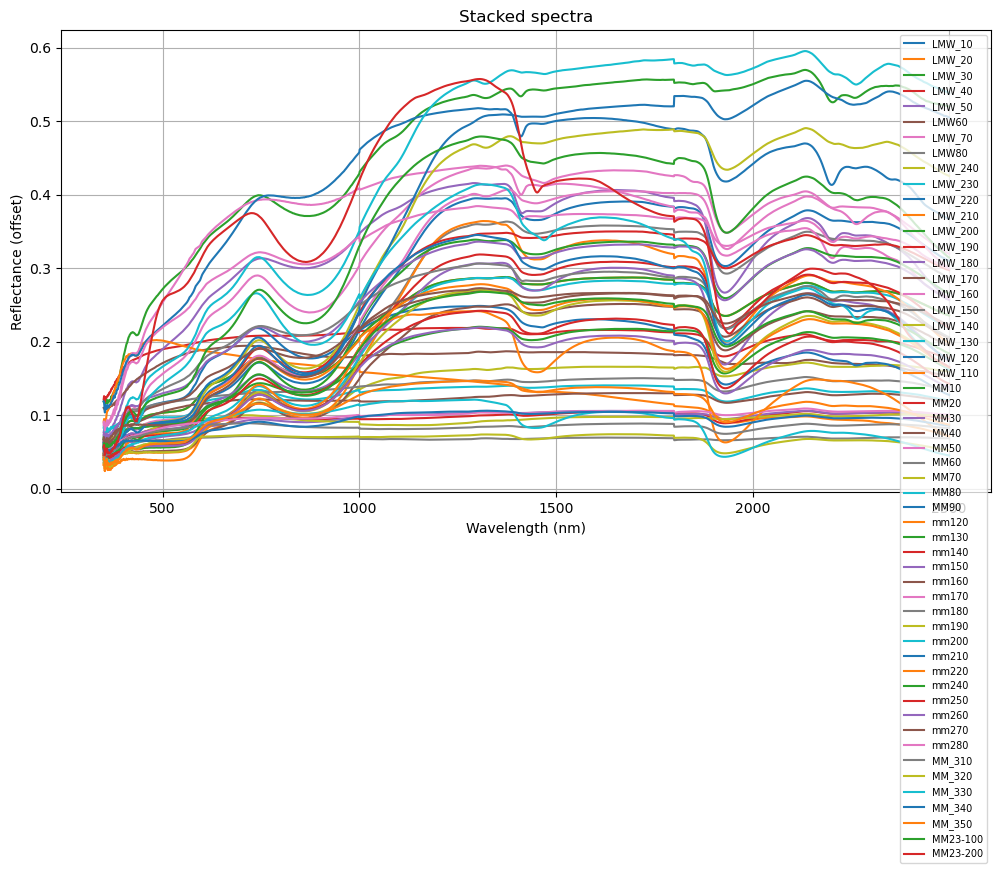

In [96]:
plt.figure(figsize=(12,6))

offset = 0
step = 0.1

for col in avg_df.columns:
    plt.plot(wl, avg_df[col], label=col)
    offset += step

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (offset)')
plt.title('Stacked spectra')
plt.grid(True)
plt.legend(fontsize=7)
plt.savefig('Group data/ASD/Figures/stacked_spectra.png', dpi=300)
plt.show()

In [97]:
pca_df = avg_df.T
pca_df.insert(0, "Sample", pca_df.index)

pca_df.to_excel("PCA_DATACOMBINED.xlsx", index=False)

In [98]:
file_path = 'PCA_DATACOMBINED.xlsx'
data = pd.read_excel(file_path)

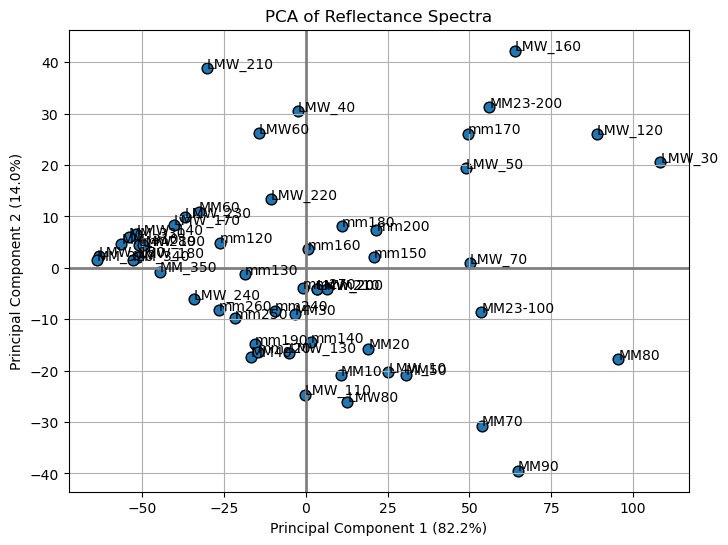

Explained Variance Ratio: [0.82188675 0.13972385 0.02851539 0.00463512]


In [99]:
from math import pi
samples = data.iloc[:, 0]
features = data.iloc[:, 1:]

# Standardize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# PCA
pca = PCA(n_components=4)
principal_components = pca.fit_transform(features_scaled)

# Create dataframe
pca_df = pd.DataFrame(principal_components, columns=['PC1','PC2','PC3','PC4'])
pca_df['Sample'] = samples

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    edgecolor='k',
    s=60
)

# Annotate samples
for i, sample in enumerate(pca_df['Sample']):
    plt.annotate(sample, (pca_df['PC1'][i], pca_df['PC2'][i]))

expl_var = pca.explained_variance_ratio_

plt.xlabel(f'Principal Component 1 ({expl_var[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({expl_var[1]*100:.1f}%)')

plt.axhline(0,color='gray',linewidth=2)
plt.axvline(0,color='gray',linewidth=2)

plt.title('PCA of Reflectance Spectra')
plt.grid(True)
plt.savefig('Group data/ASD/Figures/pca_scatter.png', dpi=300)
plt.show()

print("Explained Variance Ratio:", expl_var)

# euclidean distance

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# Transpose so samples are rows
data = avg_df.T  # rows = samples, columns = wavelengths

# Pairwise Euclidean distances between samples
dist_matrix = pdist(data, metric='euclidean')  # condensed distance matrix
dist_square = squareform(dist_matrix)          # full distance matrix (optional)

# Hierarchical clustering using Ward's method
Z = linkage(dist_matrix, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=data.index, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical clustering of spectra')
plt.ylabel('Euclidean distance')
plt.show()

# Option 1: by specifying a distance threshold
threshold = 10  # adjust based on your data
groups = fcluster(Z, t=threshold, criterion='distance')

# Option 2: by specifying number of clusters
num_clusters = 5
groups = fcluster(Z, t=num_clusters, criterion='maxclust')

# Make a DataFrame to see sample groups
group_df = pd.DataFrame({'Sample': data.index, 'Group': groups})
print(group_df)

plt.figure(figsize=(12,6))
for sample, group in zip(data.index, groups):
    plt.plot(wl, avg_df[sample], label=sample, alpha=0.7)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance')
plt.title('Spectra colored by groups')
plt.grid(True)
plt.show()

# grouped samples

In [ ]:
# grouped samples
samples = ['LMW_130000','LMW_110000','LMW_100000']
samples = [
    # LMW series
    'LMW_10',    'LMW_20',    'LMW_30',    'LMW_40',    'LMW_50',    'LMW60',    'LMW_70',    'LMW80',
    # MM series
    'MM10',    'MM20',    'MM30',    'MM40',    'MM50',    'MM60',    'MM70',    'MM80',    'MM90',
    'MM10',    'mm120',    'mm130',    'mm140',    'mm150',    'mm160',    'mm170',    'mm180',    'mm190',
    'mm200',    'mm210',    'mm220',    'mm240',    'mm250',    'mm260',    'mm270',    'mm280',
    'MM_310',    'MM_320',    'MM_330',    'MM_340',    'MM_350',
    # MM23 series
    'MM23-100',    'MM23-200',]
avg_dict = {}

for s in samples:
    pattern = f'Group data/ASD/Datacombined/{s}*.asd.txt'
    
    avg = compute_average(pattern)

    if avg is not None:
        avg_dict[s] = avg

avg_df = pd.DataFrame(avg_dict)
wl = avg_df.index.astype(float)

for col in avg_df.columns:
    plt.plot(wl, avg_df[col], label=col)
    offset += step

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (offset)')
plt.title('Stacked spectra group LMW 13, 11, 10')
plt.grid(True)
plt.legend(fontsize=7)
plt.savefig('Group data/ASD_plots/Group1.png', dpi=300)
plt.show()